In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import cm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))

primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
neutral_color = viridis_colors[3]
danger_color = viridis_colors[4]

In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\UJJWAL\Desktop\MS_Excel\Bank_Data.csv",

    encoding="latin1"
)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
# Data Cleaning 


In [10]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
45206    False
45207    False
45208    False
45209    False
45210    False
Length: 45211, dtype: bool

In [12]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [13]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Customer Distribution Across Professions

In [108]:
job_summary = (
    df['job']
    .value_counts()
    .reset_index()
)

job_summary.columns = ['Profession', 'Customers']

job_summary

,Profession,Customers
0,blue-collar,9732
1,management,9458
2,technician,7597
3,admin.,5171
4,services,4154
5,retired,2264
6,self-employed,1579
7,entrepreneur,1487
8,unemployed,1303
9,housemaid,1240


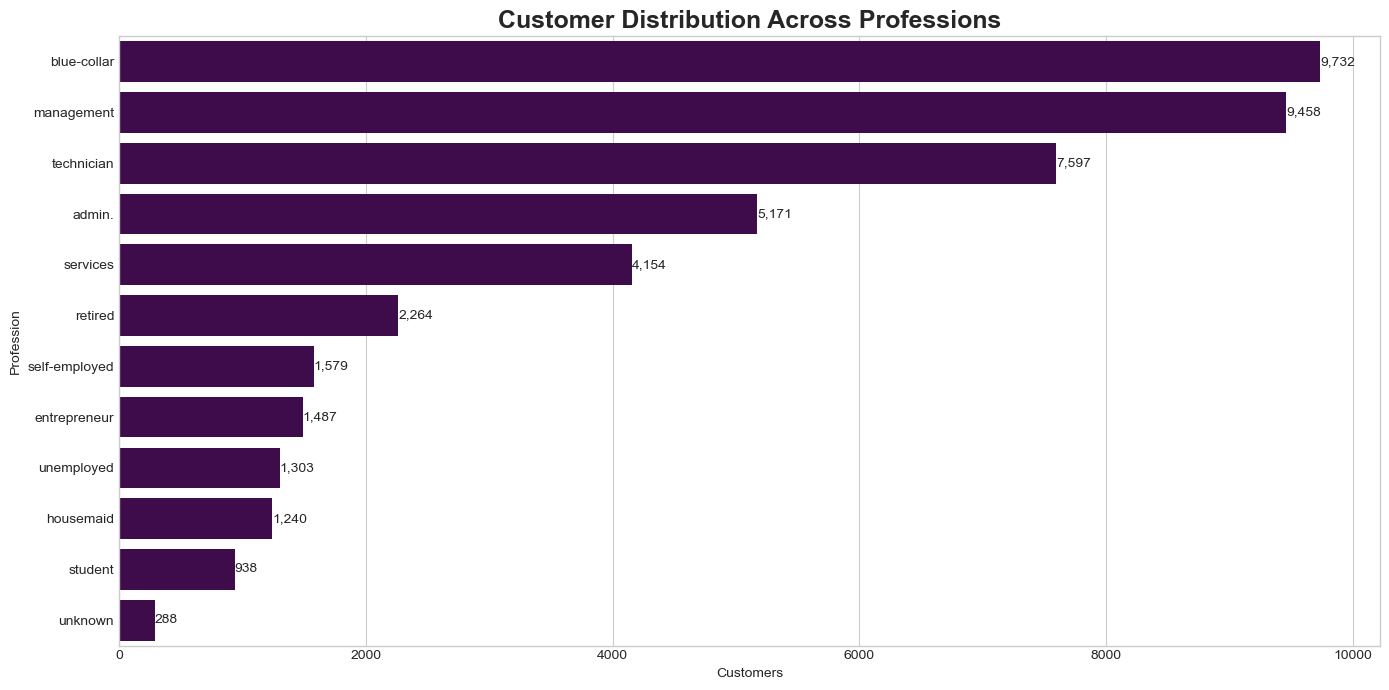

In [109]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=job_summary,
    x='Customers',
    y='Profession',
    color=primary_color
)

plt.title(
    'Customer Distribution Across Professions',
    fontsize=18,
    weight='bold'
)

for i,v in enumerate(job_summary['Customers']):
    ax.text(v, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

In [15]:
df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

Subscription Performance Across Professions

In [110]:
subscribe = df[df['y'] == 'yes']

summary = (
    subscribe.groupby('job')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='Subscribers')
)

summary

,job,Subscribers
0,management,1301
1,technician,840
2,blue-collar,708
3,admin.,631
4,retired,516
5,services,369
6,student,269
7,unemployed,202
8,self-employed,187
9,entrepreneur,123


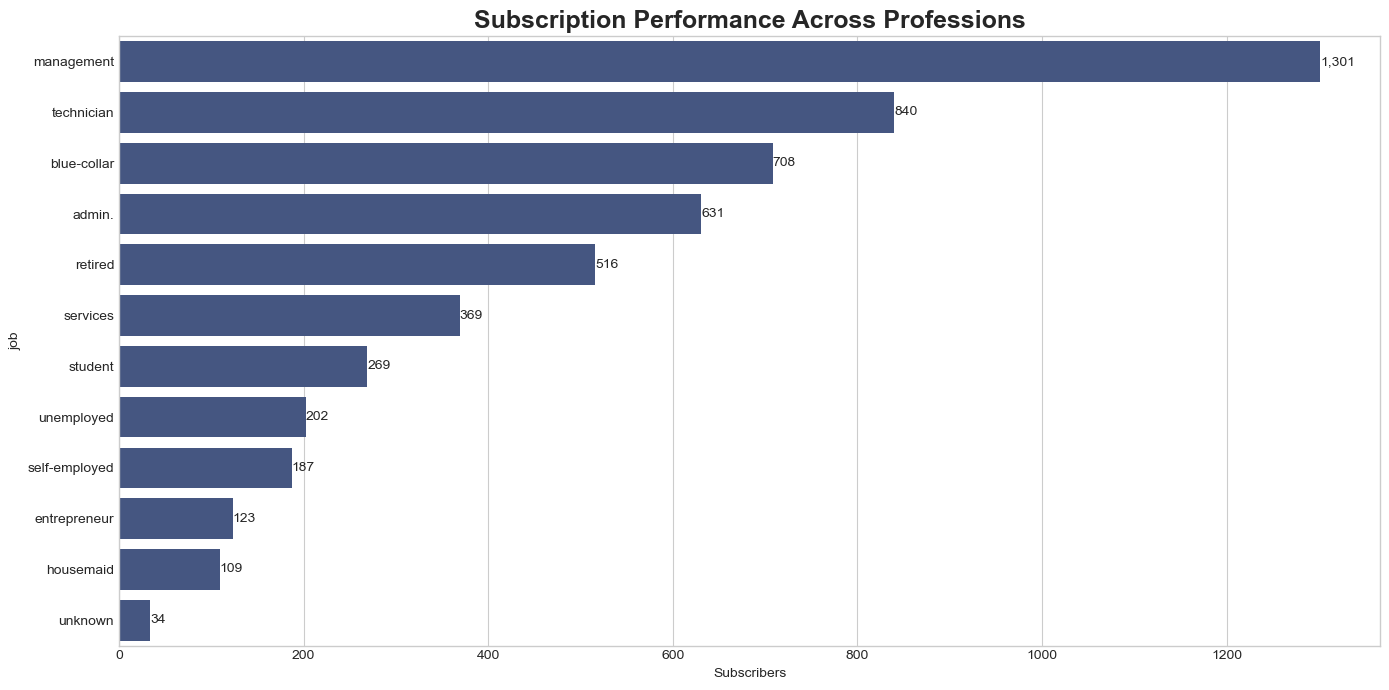

In [111]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=summary,
    x='Subscribers',
    y='job',
    color=secondary_color
)

plt.title(
    'Subscription Performance Across Professions',
    fontsize=18,
    weight='bold'
)

for i,v in enumerate(summary['Subscribers']):
    ax.text(v, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

Total Account Balance Across Professions

In [112]:
summary = (
    df.groupby('job')['balance']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='Total Balance')
)

summary

,job,Total Balance
0,management,16680288
1,blue-collar,10499141
2,technician,9516246
3,admin.,5873423
4,retired,4492263
5,services,4141904
6,self-employed,2602146
7,entrepreneur,2262426
8,unemployed,1982835
9,housemaid,1726570


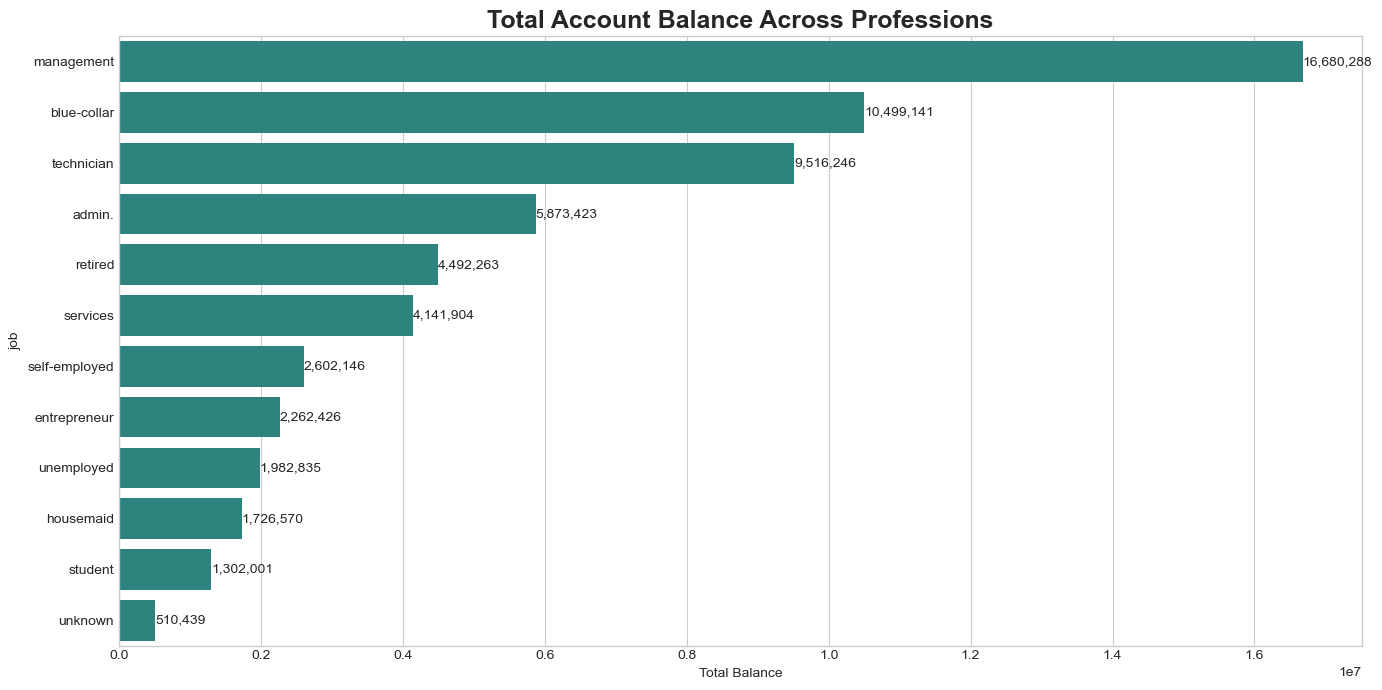

In [113]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=summary,
    x='Total Balance',
    y='job',
    color=accent_color
)

plt.title(
    'Total Account Balance Across Professions',
    fontsize=18,
    weight='bold'
)

for i,v in enumerate(summary['Total Balance']):
    ax.text(v, i, f'{v:,.0f}', va='center')

plt.tight_layout()
plt.show()

Average Account Balance Across Professions

In [115]:
summary = (
    df.groupby('job')['balance']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='Average Balance')
)

summary

,job,Average Balance
0,retired,1984.215106
1,unknown,1772.357639
2,management,1763.616832
3,self-employed,1647.970868
4,unemployed,1521.745971
5,entrepreneur,1521.470074
6,housemaid,1392.395161
7,student,1388.060768
8,technician,1252.632092
9,admin.,1135.838909


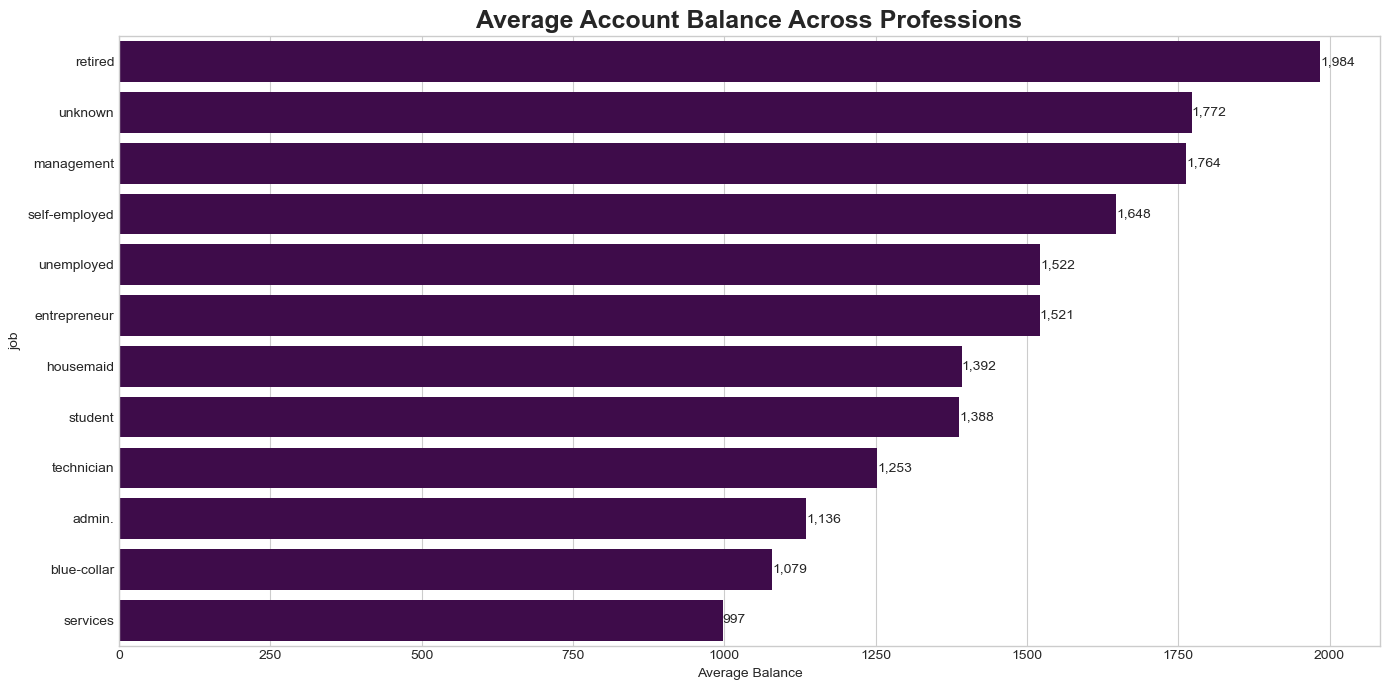

In [116]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=summary,
    x='Average Balance',
    y='job',
    color=primary_color
)

plt.title(
    'Average Account Balance Across Professions',
    fontsize=18,
    weight='bold'
)

for i,v in enumerate(summary['Average Balance']):
    ax.text(v, i, f'{v:,.0f}', va='center')

plt.tight_layout()
plt.show()

In [24]:
# Maximum balance customer in each profession
df.groupby('job')['balance'].max().sort_values(ascending=False)

job
management       102127
retired           81204
blue-collar       66653
admin.            64343
entrepreneur      59649
services          57435
self-employed     52587
technician        45248
housemaid         45141
unemployed        44134
student           24025
unknown           19706
Name: balance, dtype: int64

In [26]:
# Single customer with highest balance
df.loc[df['balance'].idxmax() , ['job' , 'balance']]

job        management
balance        102127
Name: 39989, dtype: object

Customer Distribution by Marital Status

In [117]:
summary = (
    df['marital']
    .value_counts()
    .reset_index()
)

summary.columns = ['Marital Status','Customers']

summary

,Marital Status,Customers
0,married,27214
1,single,12790
2,divorced,5207


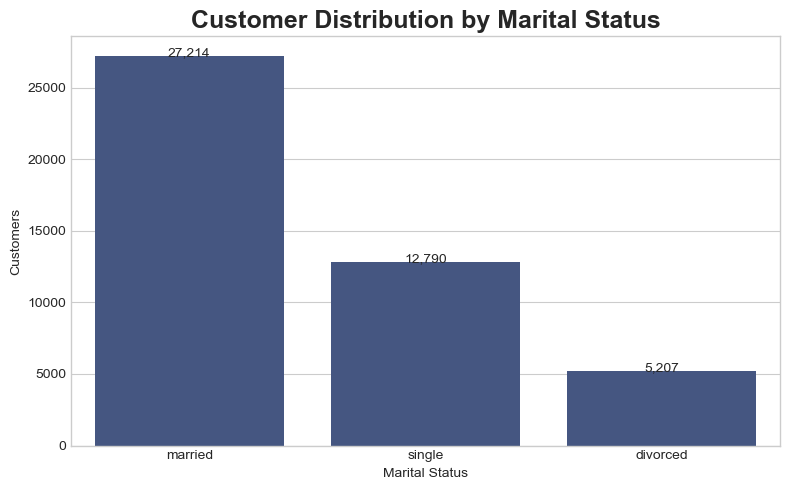

In [118]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=summary,
    x='Marital Status',
    y='Customers',
    color=secondary_color
)

plt.title(
    'Customer Distribution by Marital Status',
    fontsize=18,
    weight='bold'
)

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (
            bar.get_x()+bar.get_width()/2,
            bar.get_height()
        ),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [36]:
#Do married customers subscribe more?
df.groupby('marital')['balance'].mean().sort_values(ascending=False)

marital
married     1425.925590
single      1301.497654
divorced    1178.872287
Name: balance, dtype: float64

In [38]:
subscribe.groupby('marital').size().sort_values(ascending=False)

marital
married     2755
single      1912
divorced     622
dtype: int64

In [39]:
## Education level
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [42]:
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

Education Level Impact on Subscription Rate

In [97]:
#Creating an subscribtion flag
df['subscription']  =df['y'].map({'yes':1,'no':0})

In [119]:
summary = (
    df.groupby('education')['subscription']
    .mean()
    .mul(100)
    .reset_index(name='Subscription Rate (%)')
)

summary

,education,Subscription Rate (%)
0,primary,8.626478
1,secondary,10.559435
2,tertiary,15.006390
3,unknown,13.570275


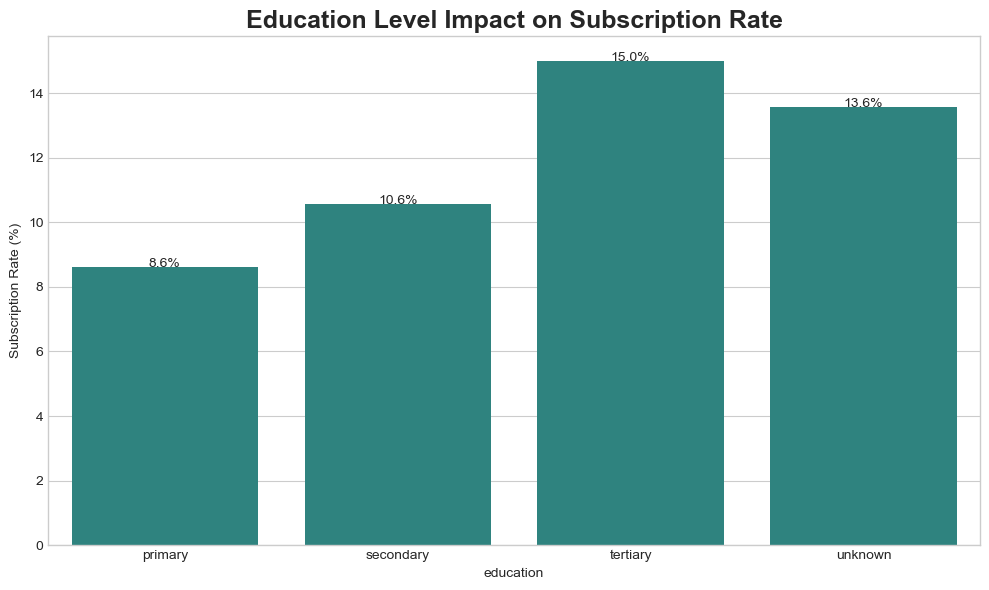

In [120]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=summary,
    x='education',
    y='Subscription Rate (%)',
    color=accent_color
)

plt.title(
    'Education Level Impact on Subscription Rate',
    fontsize=18,
    weight='bold'
)

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():.1f}%',
        (
            bar.get_x()+bar.get_width()/2,
            bar.get_height()
        ),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
#Financial Information

In [51]:
df.head(5)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscription
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


Customer Credit Default Distribution

In [122]:
summary = (
    df['default']
    .value_counts()
    .reset_index()
)

summary.columns = ['Default Status','Count']

summary

,Default Status,Count
0,no,44396
1,yes,815


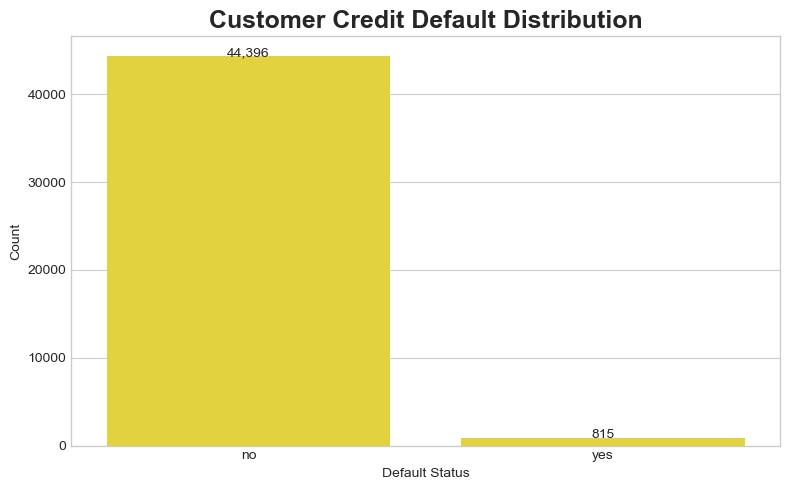

In [123]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=summary,
    x='Default Status',
    y='Count',
    color=danger_color
)

plt.title(
    'Customer Credit Default Distribution',
    fontsize=18,
    weight='bold'
)

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (
            bar.get_x()+bar.get_width()/2,
            bar.get_height()
        ),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [73]:
#Percentage of customers who defaulted
df['default_flag'] = df['default'].map({"yes":1, "no":0})
summary = (
    df['default_flag']
    .agg(
        Total_Customers='count',
        Customers_Defaulted='sum',
        Default_Rate='mean'
    )
)

summary

Total_Customers        45211.000000
Customers_Defaulted      815.000000
Default_Rate               0.018027
Name: default_flag, dtype: float64

Credit Default Rate Across Professions

In [124]:
summary = (
    df.groupby('job')['default_flag']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name='Default Rate (%)')
)

summary

,job,Default Rate (%)
0,entrepreneur,3.70
1,unemployed,2.30
2,self-employed,2.09
3,blue-collar,2.07
4,services,1.81
5,housemaid,1.77
6,management,1.73
7,technician,1.71
8,admin.,1.43
9,retired,1.15


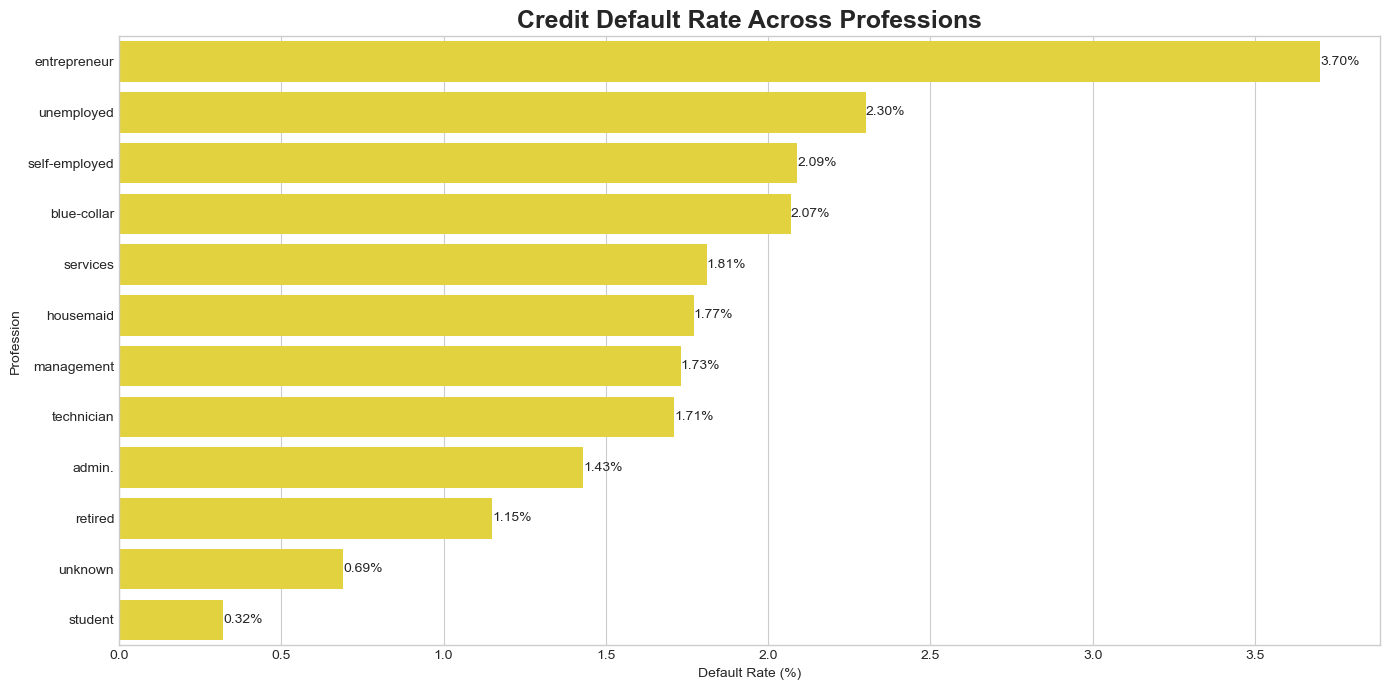

In [125]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=summary,
    x='Default Rate (%)',
    y='job',
    color=danger_color
)

plt.title(
    'Credit Default Rate Across Professions',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Default Rate (%)')
plt.ylabel('Profession')

for i,v in enumerate(summary['Default Rate (%)']):
    ax.text(v, i, f'{v:.2f}%', va='center')

plt.tight_layout()
plt.show()

In [67]:
#Does education affect subscription rate? %
summary = (
    df.groupby('education')['default_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='Default Rate (%)')
)
summary

,education,Default Rate (%)
0,primary,1.85
1,secondary,1.97
2,tertiary,1.49
3,unknown,1.72


In [61]:
#Do defaulters subscribe less?
summary = (
    df.groupby('subscription')['default_flag']
      .mean()*100
      .round(2)
      .reset_index(name='Default Rate (%)')
)

summary['subscription'] = summary['subscription'].map({
    0: 'Non-Subscribers',
    1: 'Subscribers'
})

summary

,subscription,Default Rate (%)
0,Non-Subscribers,1.91
1,Subscribers,0.98


Subscription Rate Across Balance Segments

In [88]:
df['balance_group'] = pd.qcut(
    df['balance'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [126]:
summary = (
    df.groupby('balance_group')['subscription']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='Subscription Rate (%)')
)

summary

C:\Users\UJJWAL\AppData\Local\Temp\ipykernel_4844\1877287404.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('balance_group')['subscription']


,balance_group,Subscription Rate (%)
0,Low,7.24
1,Medium,10.89
2,High,12.52
3,Very High,16.15


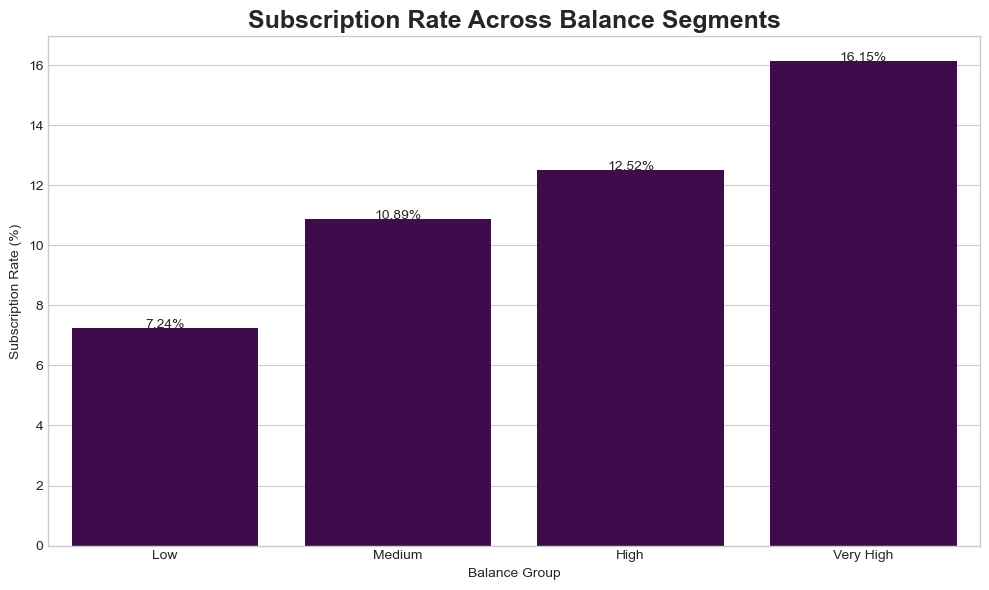

In [127]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=summary,
    x='balance_group',
    y='Subscription Rate (%)',
    color=primary_color
)

plt.title(
    'Subscription Rate Across Balance Segments',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Balance Group')
plt.ylabel('Subscription Rate (%)')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():.2f}%',
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha='center'
    )

plt.tight_layout()
plt.show()

Housing Loan Influence on Campaign Success

In [91]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'subscription', 'default_flag',
       'Default_flagg', 'balance_group'],
      dtype='object')

In [128]:
summary = (
    df.groupby('housing')['subscription']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='Subscription Rate (%)')
)

summary

,housing,Subscription Rate (%)
0,no,16.7
1,yes,7.7


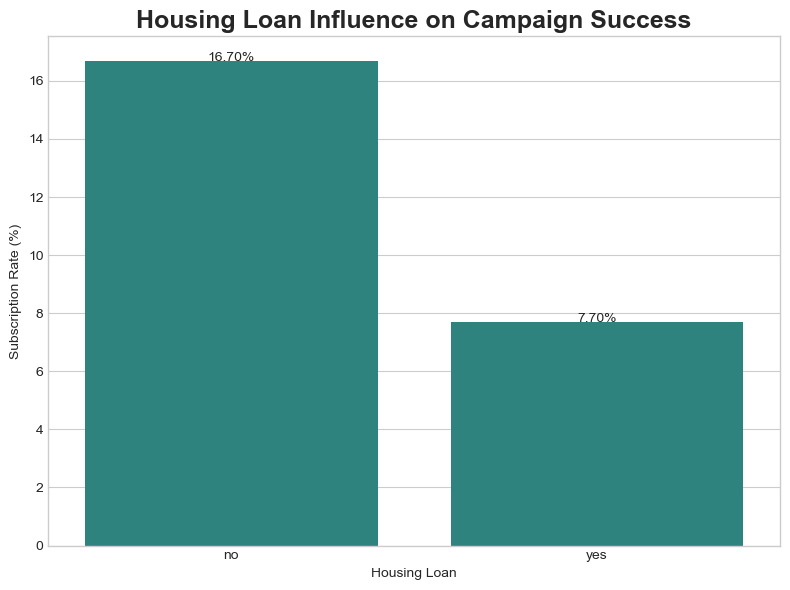

In [129]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=summary,
    x='housing',
    y='Subscription Rate (%)',
    color=accent_color
)

plt.title(
    'Housing Loan Influence on Campaign Success',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Housing Loan')
plt.ylabel('Subscription Rate (%)')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():.2f}%',
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [94]:
df["loan"]

0         no
1         no
2        yes
3         no
4         no
        ... 
45206     no
45207     no
45208     no
45209     no
45210     no
Name: loan, Length: 45211, dtype: object

Which numerical variables are most associated with subscription behavior?

Correlation Analysis of Banking Variables

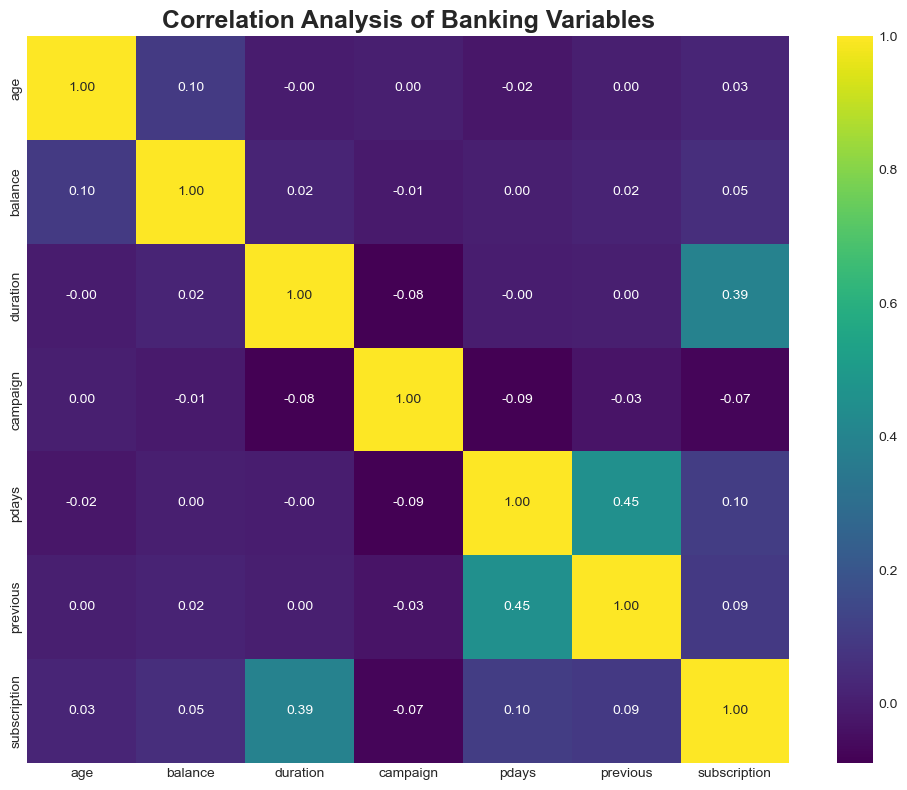

In [130]:
corr_df = df.copy()

corr_df['subscription'] = corr_df['subscription'].astype(int)

columns = [
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'subscription'
]

corr_matrix = corr_df[columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title(
    'Correlation Analysis of Banking Variables',
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

Which professions have the highest conversion rates?

Job vs Subscription Stacked Bar Chart

In [131]:
job_sub = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

job_sub

y,no,yes
job,,
admin.,87.797331,12.202669
blue-collar,92.725031,7.274969
entrepreneur,91.728312,8.271688
housemaid,91.209677,8.790323
management,86.244449,13.755551
retired,77.208481,22.791519
self-employed,88.157061,11.842939
services,91.116996,8.883004
student,71.321962,28.678038


Balance vs Subscription Boxplot

Do subscribers maintain different account balances than non-subscribers?

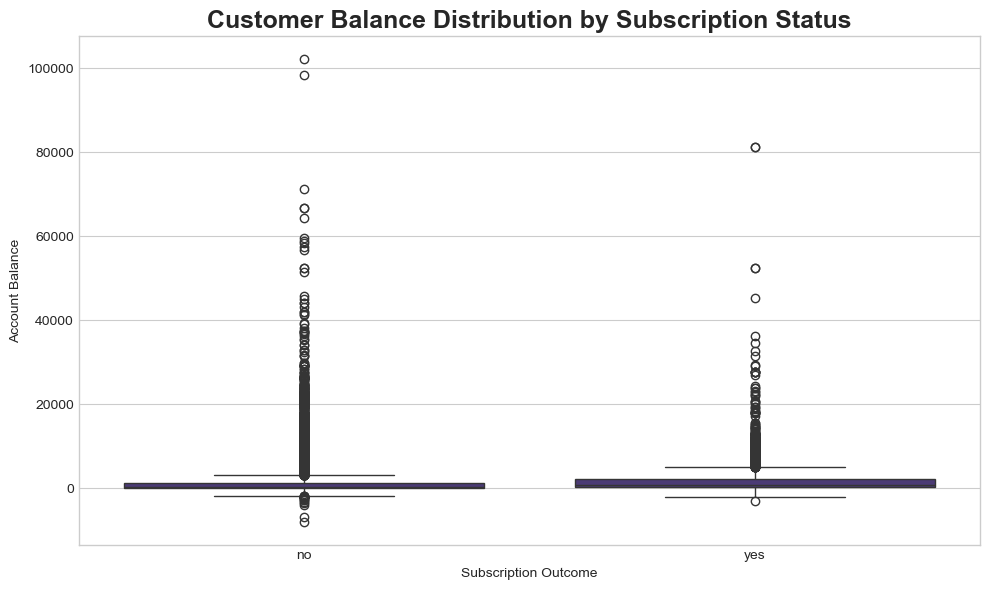

In [132]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='y',
    y='balance'
)

plt.title(
    'Customer Balance Distribution by Subscription Status',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Subscription Outcome')
plt.ylabel('Account Balance')

plt.tight_layout()
plt.show()